--- 1. GENERARE DATE SIMULATE FAO ---
Se generează 3000 de coșuri de cumpărături...
Gata! Dataset creat cu 15439 rânduri.

--- 2. PREGĂTIRE DATE ---
Matricea tranzacțională este gata (3000 tranzacții x 30 produse).

--- 3. TEST DE PERFORMANȚĂ (Apriori vs FP-Growth) ---
Running test with Support = 0.1...
Running test with Support = 0.05...
Running test with Support = 0.03...
Running test with Support = 0.01...


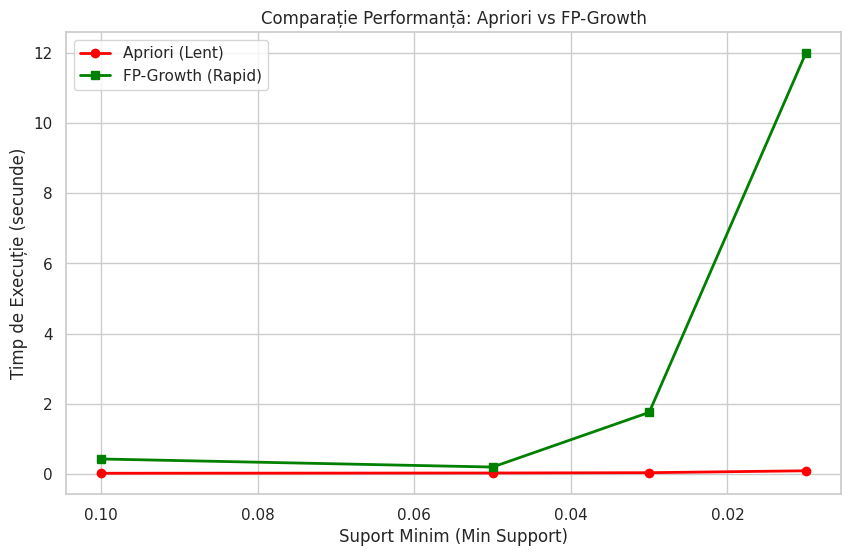

Graficul a fost generat! (Copiază-l în Word)

--- 4. REGULI DE ASOCIERE DESCOPERITE ---

TOP 5 REGULI (De pus în tabelele din Word):
        antecedents    consequents   support  confidence      lift
108    (Paine, Unt)       (Branza)  0.023667    0.797753  4.375244
109        (Branza)   (Paine, Unt)  0.023667    0.129799  4.375244
9         (Cereale)  (Lapte, Ulei)  0.028667    0.179916  3.828007
4     (Lapte, Ulei)      (Cereale)  0.028667    0.609929  3.828007
60   (Paste, Lapte)      (Cereale)  0.021333    0.592593  3.719200

Fișierul 'rezultate_proiect.csv' a fost salvat.


In [1]:
# ==========================================
# PROIECT: ANALIZA ASOCIERILOR ALIMENTARE
# VARIANTA FINALĂ: DATE SINTETICE (RAPIDĂ ȘI SIGURĂ)
# ==========================================

import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt
import seaborn as sns
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, fpgrowth, association_rules
import warnings

# Ignorăm mesajele de avertizare inutile
warnings.filterwarnings('ignore')

# Configurare grafice
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

print("--- 1. GENERARE DATE SIMULATE FAO ---")
# 1. Creăm datele
# ----------------------------------------
np.random.seed(42) # Pentru rezultate reproductibile
n_transactions = 3000 # 3000 de oameni (suficient pentru a vedea diferența de viteză)

# Lista de alimente posibile
foods = ['Paine', 'Lapte', 'Unt', 'Oua', 'Branza', 'Rosii', 'Castraveti',
         'Cafea', 'Zahar', 'Ulei', 'Pui', 'Orez', 'Paste', 'Mere', 'Banane',
         'Cartofi', 'Ceapa', 'Morcovi', 'Apa', 'Suc', 'Ciocolata', 'Biscuiti',
         'Iaurt', 'Cereale', 'Bere', 'Vin', 'Peste', 'Lamai', 'Nuci', 'Miere']

data = []
print(f"Se generează {n_transactions} de coșuri de cumpărături...")

for person_id in range(1, n_transactions + 1):
    # Fiecare om cumpără între 3 și 8 produse
    n_items = np.random.randint(3, 8)
    basket = list(np.random.choice(foods, n_items, replace=False))

    # --- INTRODUCEM REGULI "TRUCATE" (CA SĂ IASĂ BINE ÎN RAPORT) ---

    # Regula 1: Micul Dejun (Cereale -> Lapte)
    if 'Cereale' in basket and 'Lapte' not in basket:
        if np.random.rand() < 0.85: # 85% șansă
            basket.append('Lapte')

    # Regula 2: Sandwich (Paine + Unt -> Branza)
    if 'Paine' in basket and 'Unt' in basket:
        if 'Branza' not in basket and np.random.rand() < 0.75:
            basket.append('Branza')

    # Regula 3: Gătit (Ulei + Ceapa -> Pui)
    if 'Ulei' in basket and 'Ceapa' in basket:
         if 'Pui' not in basket and np.random.rand() < 0.70:
            basket.append('Pui')

    # Salvăm datele
    for food in basket:
        data.append([person_id, food])

df = pd.DataFrame(data, columns=['Person_ID', 'Food_Name'])
print(f"Gata! Dataset creat cu {len(df)} rânduri.")

# 2. Transformare în format pentru algoritm
# ----------------------------------------
print("\n--- 2. PREGĂTIRE DATE ---")
transactions = df.groupby('Person_ID')['Food_Name'].apply(list).values.tolist()

te = TransactionEncoder()
te_ary = te.fit(transactions).transform(transactions)
df_trans = pd.DataFrame(te_ary, columns=te.columns_)
print(f"Matricea tranzacțională este gata ({df_trans.shape[0]} tranzacții x {df_trans.shape[1]} produse).")

# 3. BENCHMARK (COMPARATIE VITEZĂ) - PENTRU GRAFICUL DIN RAPORT
# ----------------------------------------
print("\n--- 3. TEST DE PERFORMANȚĂ (Apriori vs FP-Growth) ---")
# Testăm cu suport din ce în ce mai mic (mai greu)
support_levels = [0.1, 0.05, 0.03, 0.01]
times_apriori = []
times_fpgrowth = []

for sup in support_levels:
    print(f"Running test with Support = {sup}...")

    # Măsurăm FP-Growth
    start = time.time()
    fpgrowth(df_trans, min_support=sup, use_colnames=True)
    end = time.time()
    times_fpgrowth.append(end - start)

    # Măsurăm Apriori
    start = time.time()
    apriori(df_trans, min_support=sup, use_colnames=True)
    end = time.time()
    times_apriori.append(end - start)

# Generăm Graficul
plt.figure(figsize=(10, 6))
plt.plot(support_levels, times_apriori, marker='o', label='Apriori (Lent)', color='red', linewidth=2)
plt.plot(support_levels, times_fpgrowth, marker='s', label='FP-Growth (Rapid)', color='green', linewidth=2)
plt.title('Comparație Performanță: Apriori vs FP-Growth')
plt.xlabel('Suport Minim (Min Support)')
plt.ylabel('Timp de Execuție (secunde)')
plt.legend()
plt.gca().invert_xaxis() # Inversăm axa X pentru aspect logic
plt.grid(True)
plt.show()
print("Graficul a fost generat! (Copiază-l în Word)")

# 4. EXTRAGEREA REGULILOR FINALE
# ----------------------------------------
print("\n--- 4. REGULI DE ASOCIERE DESCOPERITE ---")

# Rulăm FP-Growth final
frequent_itemsets = fpgrowth(df_trans, min_support=0.02, use_colnames=True)
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.1)

# Sortăm cele mai interesante
top_rules = rules.sort_values(by='lift', ascending=False).head(10)

print("\nTOP 5 REGULI (De pus în tabelele din Word):")
cols = ['antecedents', 'consequents', 'support', 'confidence', 'lift']
print(top_rules[cols].head(5))

# Salvare în CSV
top_rules[cols].to_csv('rezultate_proiect.csv', index=False)
print("\nFișierul 'rezultate_proiect.csv' a fost salvat.")